# Mobile Phone Price Prediction
This notebook performs data cleaning, feature engineering, machine learning modeling, and visualization.

## 1. Install libraries (run only if needed)

In [23]:
# Uncomment if running in a new environment
# !pip install pandas numpy matplotlib seaborn scikit-learn shap openpyxl

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



## 3. Load Dataset

In [2]:
df = pd.read_excel("Processed_Flipdata (2).xlsx")
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


## 4. Dataset Exploration

In [3]:
print("Dataset Shape:", df.shape)
print(df.info())
df.describe()

Dataset Shape: (541, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 50.8+ KB
None


,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height,Prize
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,289.711645,110.550832,5.397412,4871.587800,0.062847,16.431201,16228.375231
std,182.359185,60.600694,1.984923,780.148862,0.242911,2.523553,10793.588322
min,0.000000,16.000000,2.000000,800.000000,0.000000,4.500000,920.000000
25%,135.000000,64.000000,4.000000,5000.000000,0.000000,16.510000,9290.000000
50%,273.000000,128.000000,6.000000,5000.000000,0.000000,16.710000,13499.000000
75%,434.000000,128.000000,8.000000,5000.000000,0.000000,16.940000,19280.000000
max,642.000000,256.000000,8.000000,7000.000000,1.000000,41.940000,80999.000000


## 5. Data Cleaning

In [4]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

def extract_mp(val):
    if isinstance(val, str):
        num = ''.join([c for c in val if c.isdigit()])
        return float(num) if num != '' else np.nan
    return val

if "Rear Camera" in df.columns:
    df["Rear Camera MP"] = df["Rear Camera"].apply(extract_mp)

if "Front Camera" in df.columns:
    df["Front Camera MP"] = df["Front Camera"].apply(extract_mp)

df = df.drop(columns=[c for c in ["Rear Camera","Front Camera"] if c in df.columns])

# Fill missing numeric values
df = df.fillna(df.median(numeric_only=True))

df.head()


,Model,Colour,Memory,RAM,Battery_,AI Lens,Mobile Height,Processor_,Prize,Rear Camera MP,Front Camera MP
0,Infinix SMART 7,Night Black,64,4,6000,1,16.76,Unisoc Spreadtrum SC9863A1,7299,13.0,5.0
1,Infinix SMART 7,Azure Blue,64,4,6000,1,16.76,Unisoc Spreadtrum SC9863A1,7299,13.0,5.0
2,MOTOROLA G32,Mineral Gray,128,8,5000,0,16.64,Qualcomm Snapdragon 680,11999,50.0,16.0
3,POCO C50,Royal Blue,32,2,5000,0,16.56,Mediatek Helio A22,5649,8.0,5.0
4,Infinix HOT 30i,Marigold,128,8,5000,1,16.76,G37,8999,50.0,5.0


## 6. Separate Features and Target

In [5]:
target = "Prize"
y = df[target]
X = df.drop(columns=[target])

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical Columns:", list(categorical_cols))
print("Numeric Columns:", list(numeric_cols))


Categorical Columns: ['Model', 'Colour', 'Processor_']
Numeric Columns: ['Memory', 'RAM', 'Battery_', 'AI Lens', 'Mobile Height', 'Rear Camera MP', 'Front Camera MP']


## 7. One‑Hot Encoding (Explicit Preview)

In [6]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

encoded = encoder.fit_transform(X[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

encoded_df.head()


c:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,Model_APPLE iPhone 11,Model_APPLE iPhone 12,Model_APPLE iPhone 14 Plus,Model_Google Pixel 6a,Model_Google Pixel 7,Model_Google Pixel 7a,Model_I Kall Z19Pro,Model_I Kall Z19Pro Flash blue,Model_IQOO Neo 7 5G,Model_Infinix HOT 12 Play,...,Processor__Unisoc Spreadtrum SC9863A1,Processor__Unisoc T606,Processor__Unisoc T610,Processor__Unisoc T612,Processor__Unisoc T612 processor,Processor__Unisoc T616,Processor__Unisoc Tiger T612 (12 nm),Processor__Unisoc Tiger T616,Processor__ios,Processor__snapdragon 888
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Combine encoded categorical with numeric features
numeric_df = X[numeric_cols].reset_index(drop=True)
X_encoded = pd.concat([encoded_df, numeric_df], axis=1)

X_encoded.head()


,Model_APPLE iPhone 11,Model_APPLE iPhone 12,Model_APPLE iPhone 14 Plus,Model_Google Pixel 6a,Model_Google Pixel 7,Model_Google Pixel 7a,Model_I Kall Z19Pro,Model_I Kall Z19Pro Flash blue,Model_IQOO Neo 7 5G,Model_Infinix HOT 12 Play,...,Processor__Unisoc Tiger T616,Processor__ios,Processor__snapdragon 888,Memory,RAM,Battery_,AI Lens,Mobile Height,Rear Camera MP,Front Camera MP
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,64,4,6000,1,16.76,13.0,5.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,64,4,6000,1,16.76,13.0,5.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,128,8,5000,0,16.64,50.0,16.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,32,2,5000,0,16.56,8.0,5.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,128,8,5000,1,16.76,50.0,5.0


## 8. Correlation Heatmap

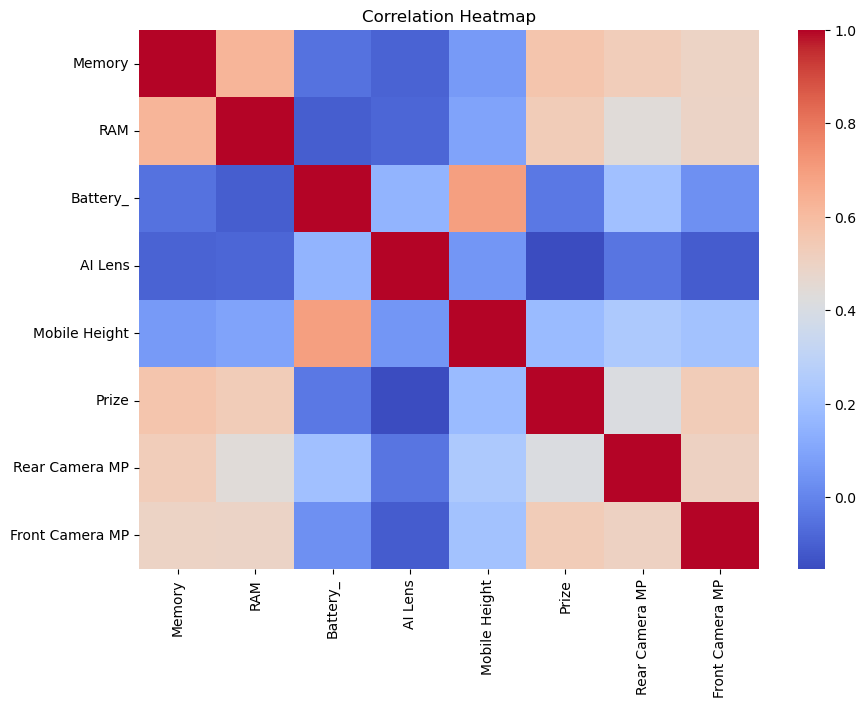

In [8]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## 9. Pairplot (Sampled to avoid memory errors)

c:\Users\HP\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


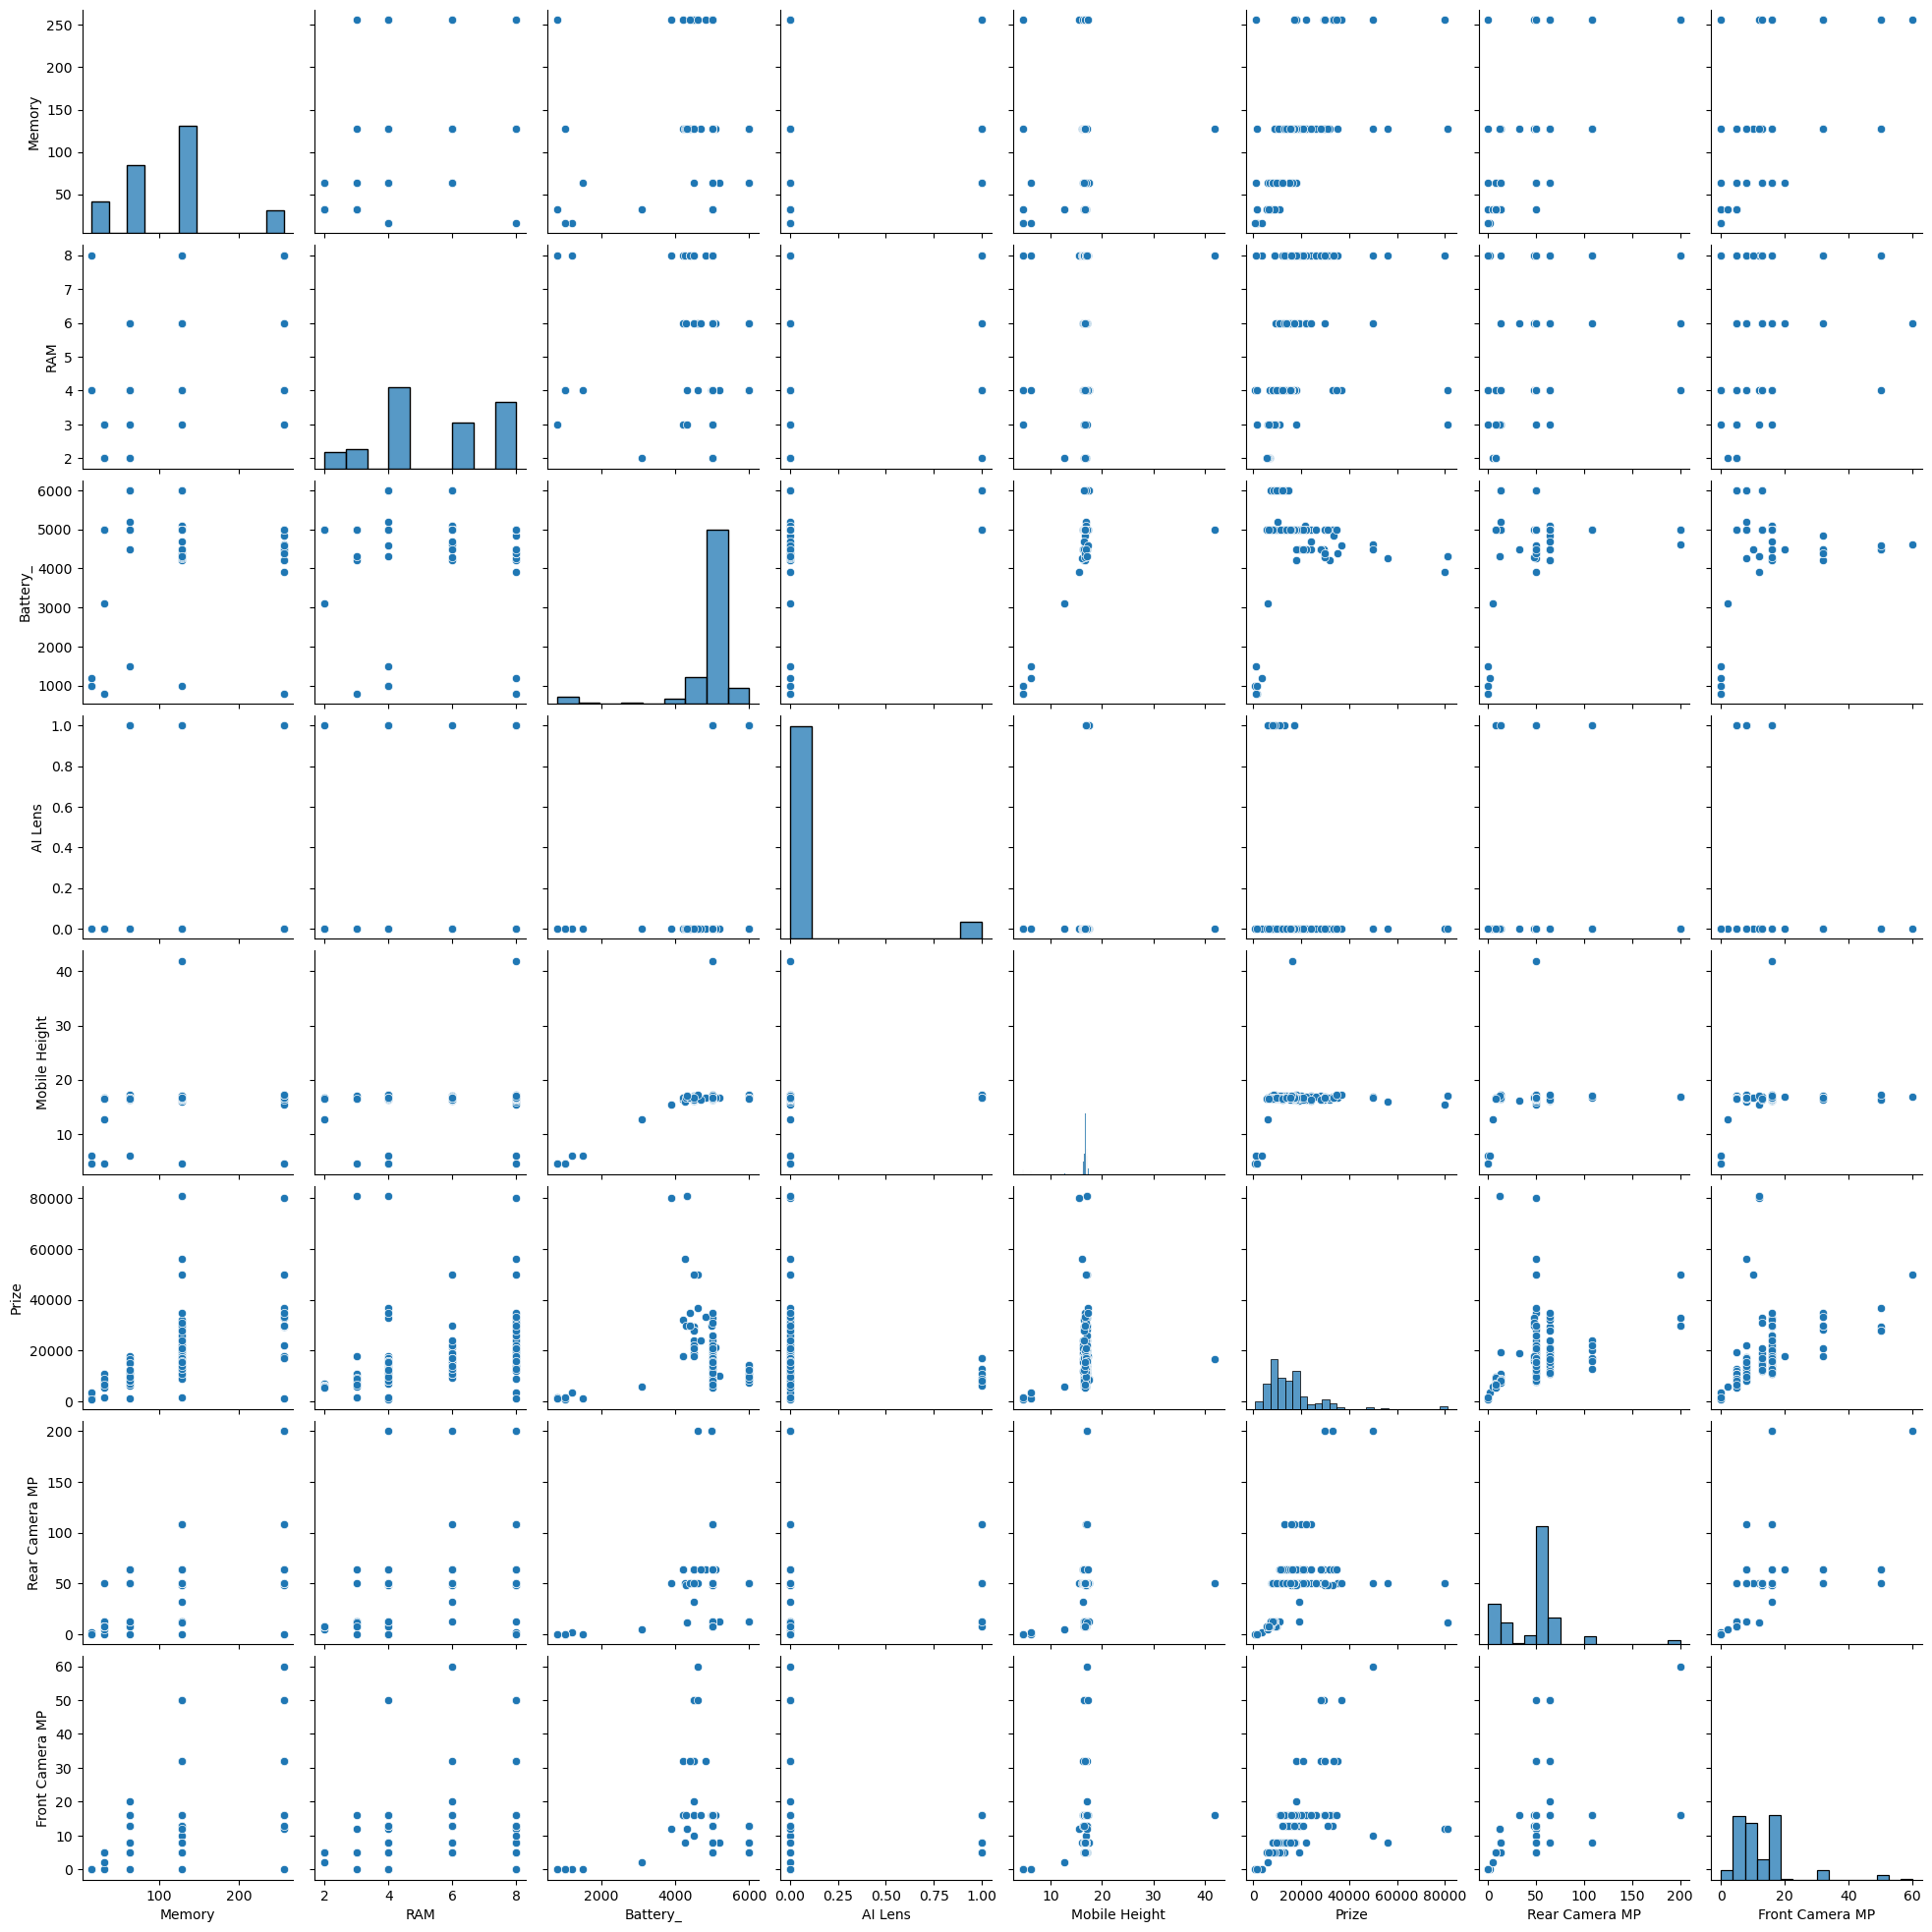

In [9]:
sample_df = df.select_dtypes(include=[np.number]).sample(min(200,len(df)), random_state=42)
sns.pairplot(sample_df)
plt.show()


## 10. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)


## 11. Train Machine Learning Models

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor()
}


results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model","MAE","RMSE","R2"])
results_df


,Model,MAE,RMSE,R2
0,Linear Regression,4.266550e+11,1.835490e+12,-2.444373e+16
1,Random Forest,1.804964e+03,4.669909e+03,8.417732e-01
2,Gradient Boosting,2.238215e+03,4.974819e+03,8.204367e-01


## 12. Model Comparison Visualization

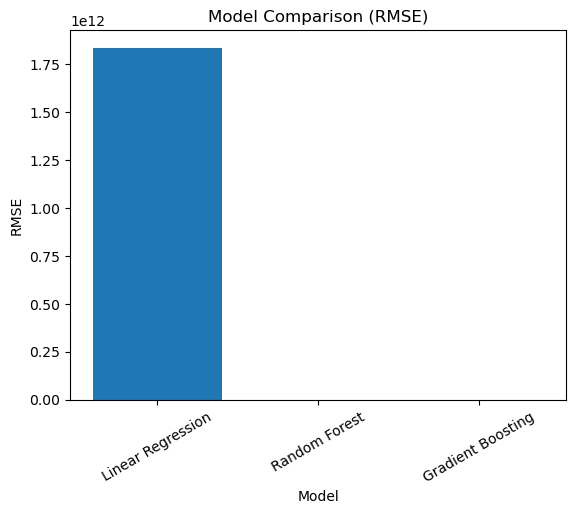

In [12]:
plt.figure()
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.show()


## 13. Feature Importance (Random Forest)

In [36]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(15)

feat_df


,Feature,Importance
591,Front Camera MP,0.414839
587,Battery_,0.089839
585,Memory,0.084162
2,Model_APPLE iPhone 14 Plus,0.059784
586,RAM,0.058085
4,Model_Google Pixel 7,0.051049
478,Processor__Google Tensor G2,0.041013
589,Mobile Height,0.037226
590,Rear Camera MP,0.030960
109,Model_SAMSUNG Galaxy A34 5G,0.005629


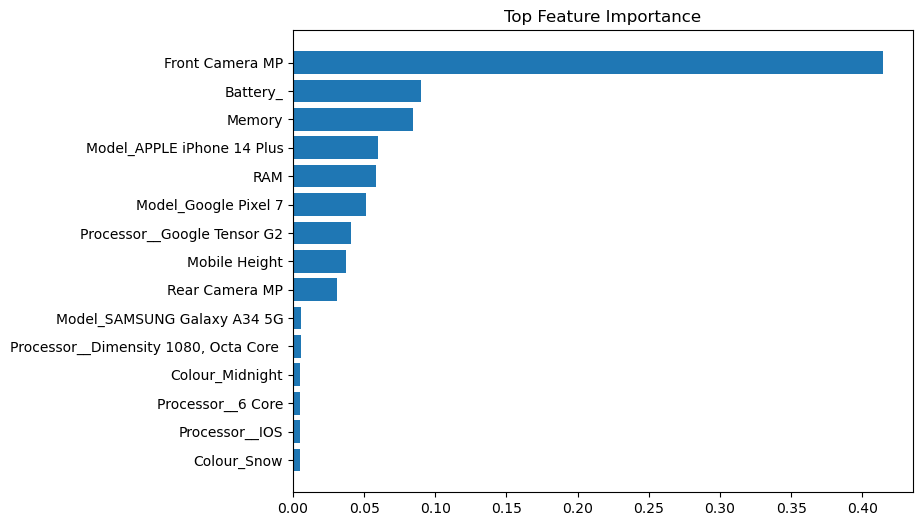

In [37]:
plt.figure(figsize=(8,6))
plt.barh(feat_df["Feature"][::-1], feat_df["Importance"][::-1])
plt.title("Top Feature Importance")
plt.show()


## 14. Price Distribution

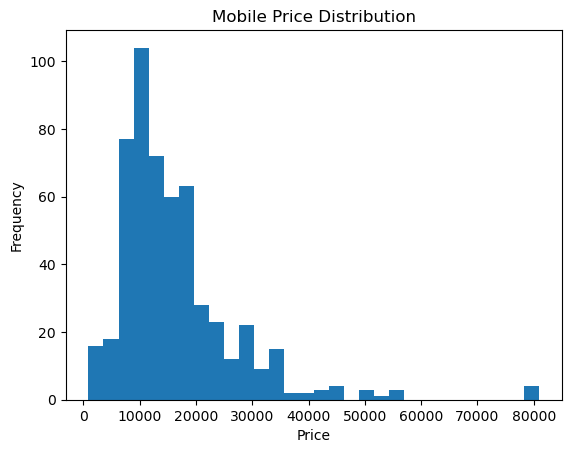

In [21]:
plt.figure()
plt.hist(df["Prize"], bins=30)
plt.title("Mobile Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


## 15. Actual vs Predicted Prices

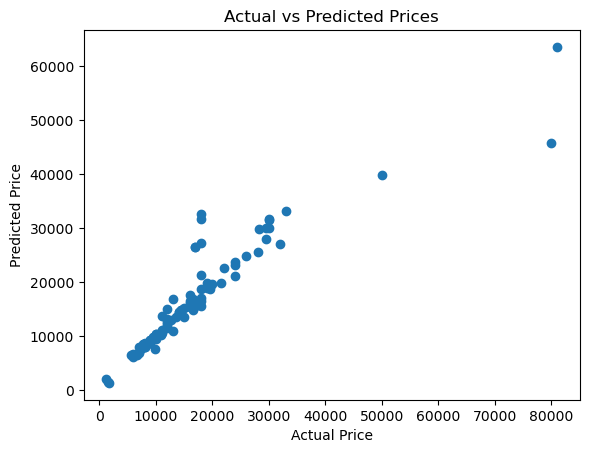

In [38]:
pred = rf.predict(X_test)

plt.figure()
plt.scatter(y_test, pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()


# Additional Evaluation & Visualization
This section adds optimized model comparison and visualization including:
- Combined comparison chart (MAE, RMSE, R²)
- Feature importance
- Actual vs Predicted plot
- Residual error plot

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4.266550e+11,1.835490e+12,-2.444373e+16
1,Random Forest,1.804964e+03,4.669909e+03,8.417732e-01
2,Gradient Boosting,2.264920e+03,5.022705e+03,8.169632e-01


## Combined Model Comparison Chart

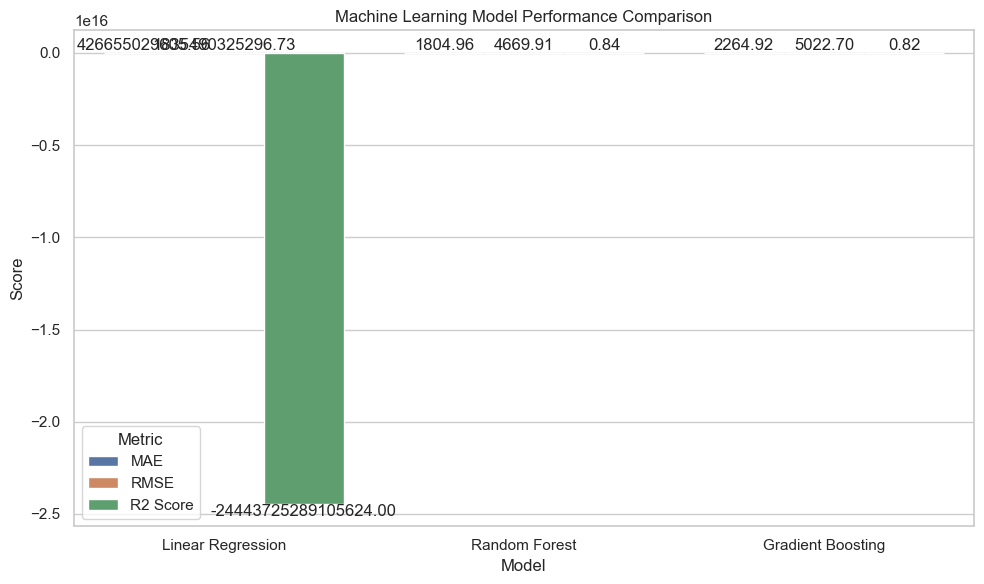

In [14]:
results_long = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x="Model",
    y="Score",
    hue="Metric",
    data=results_long
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Machine Learning Model Performance Comparison")
plt.tight_layout()
plt.show()

## Feature Importance (Random Forest)

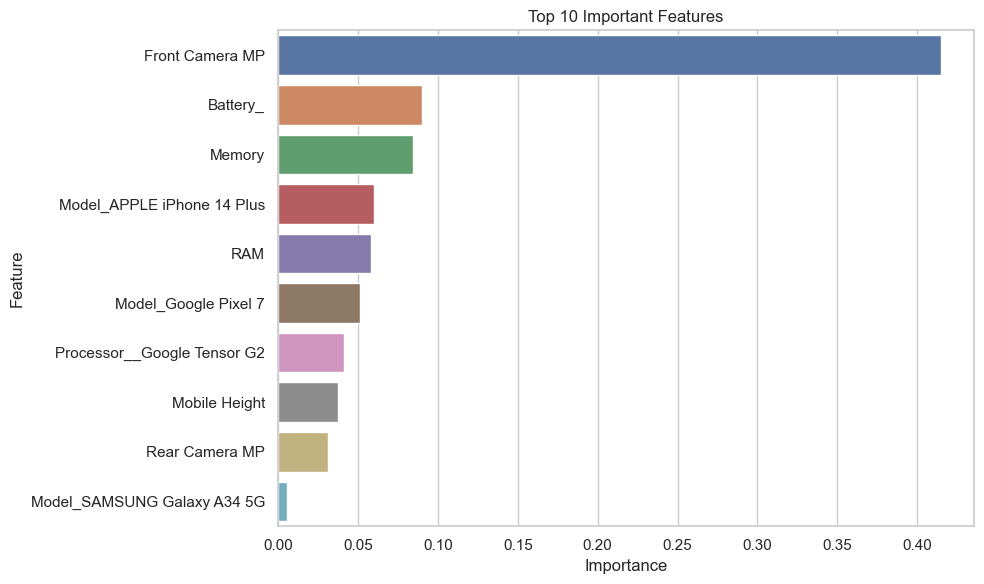

In [15]:
rf_model = models["Random Forest"]

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

## Actual vs Predicted Plot

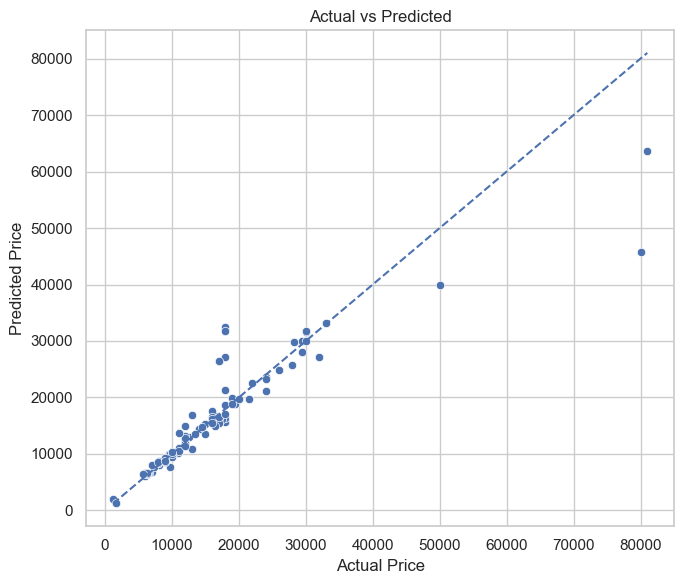

In [16]:
best_model = models["Random Forest"]
predictions = best_model.predict(X_test)

plt.figure(figsize=(7,6))

sns.scatterplot(x=y_test, y=predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

## Residual Error Plot

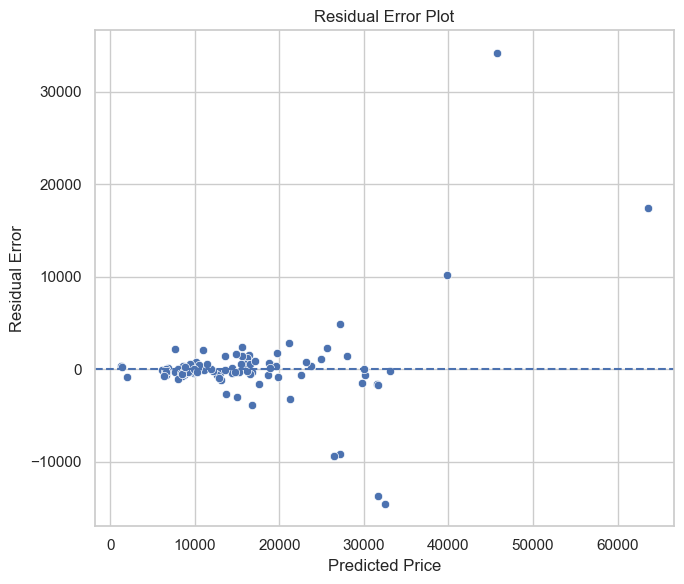

In [17]:
residuals = y_test - predictions

plt.figure(figsize=(7,6))

sns.scatterplot(x=predictions, y=residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual Error")
plt.title("Residual Error Plot")
plt.tight_layout()
plt.show()